In [12]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# 1. PENGATURAN PATH & CONFIGURATION
# ==========================================
# Pastikan script python ini berada di folder yang sama dengan folder 'data'
DATA_DIR = "datasetBuah2/train/train" # Ganti dengan path dataset Anda jika berbeda
IMG_SIZE = (224, 224) # Mengubah semua ukuran gambar menjadi 224x224 piksel
BATCH_SIZE = 32

# ==========================================
# 2. LOADING DATASET (Otomatis Split Train & Val)
# ==========================================
# Memuat data untuk Training (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Memuat data untuk Validasi/Testing (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Mengambil nama-nama kelas berdasarkan nama folder
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nTotal Kelas ditemukan: {num_classes}")
print(f"Daftar Kelas: {class_names}\n")

# Optimasi performa loading data ke memori
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 3. MEMBANGUN MODEL CNN (Convolutional Neural Network)
# ==========================================
model = models.Sequential([
    # Rescaling untuk mengubah nilai pixel dari 0-255 menjadi 0-1
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # Feature Extraction (Mempelajari pola gambar)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flattening & Fully Connected Layer (Klasifikasi keputusan)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Mencegah overfitting
    layers.Dense(num_classes, activation='softmax') # Output sesuai jumlah kelas
])

# ==========================================
# 4. COMPILE & TRAINING MODEL
# ==========================================
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

# Mulai proses training (silakan naikkan epochs jika akurasi kurang tinggi)
EPOCHS = 50
print("\nMemulai Training Model...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# ==========================================
# 5. MENYIMPAN MODEL
# ==========================================
model.save('model_klasifikasi_makanan.h5')
print("\nModel sukses dilatih dan disimpan dengan nama 'model_klasifikasi_makanan.h5'!")

Found 16854 files belonging to 33 classes.
Using 13484 files for training.
Found 16854 files belonging to 33 classes.
Using 3370 files for validation.

Total Kelas ditemukan: 33
Daftar Kelas: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']



c:\Users\MyPC PRO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 33)             │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,217 (42.62 MB)

 Trainable params: 11,173,217 (42.62 MB)

 Non-trainable params: 0 (0.00 B)


Memulai Training Model...
Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 121s 281ms/step - accuracy: 0.7817 - loss: 0.7452 - val_accuracy: 0.9964 - val_loss: 0.0145
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 122s 289ms/step - accuracy: 0.9581 - loss: 0.1285 - val_accuracy: 0.9935 - val_loss: 0.0237
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 122s 288ms/step - accuracy: 0.9671 - loss: 0.0973 - val_accuracy: 1.0000 - val_loss: 7.1774e-04
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 122s 289ms/step - accuracy: 0.9701 - loss: 0.0959 - val_accuracy: 1.0000 - val_loss: 7.9278e-05
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 122s 289ms/step - accuracy: 0.9838 - loss: 0.0454 - val_accuracy: 0.9955 - val_loss: 0.0116
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 121s 288ms/step - accuracy: 0.9769 - loss: 0.0875 - val_accuracy: 1.0000 - val_loss: 7.1077e-06
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 122s 288ms/step - accuracy: 0.9795 - loss: 0.0618 - val_accuracy: 1.0000 - val_loss: 2.0368e-04
Epoch 8/50
422/422 ━━━━━━━━━━━━━━


Model sukses dilatih dan disimpan dengan nama 'model_klasifikasi_makanan.h5'!



[INFO] Menghitung Evaluasi Model...
106/106 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 1.0000 - loss: 1.1107e-08
Akurasi Validasi : 100.00%
Loss Validasi    : 0.0000

[INFO] Membuat Grafik Performa Training...


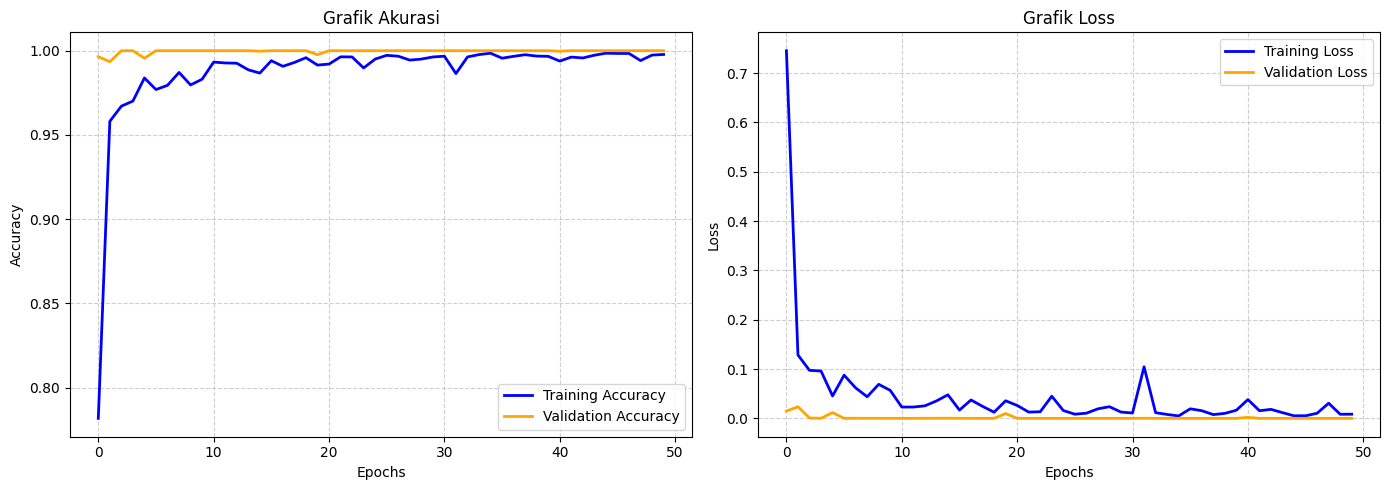


[INFO] Menghitung prediksi untuk Classification Report...
106/106 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step

               CLASSIFICATION REPORT
                    precision    recall  f1-score   support

    Apple Braeburn       1.00      1.00      1.00       104
Apple Granny Smith       1.00      1.00      1.00        92
           Apricot       1.00      1.00      1.00        95
           Avocado       1.00      1.00      1.00        90
            Banana       1.00      1.00      1.00       108
         Blueberry       1.00      1.00      1.00        84
      Cactus fruit       1.00      1.00      1.00       108
        Cantaloupe       1.00      1.00      1.00        98
            Cherry       1.00      1.00      1.00       112
        Clementine       1.00      1.00      1.00       100
              Corn       1.00      1.00      1.00        87
     Cucumber Ripe       1.00      1.00      1.00        73
        Grape Blue       1.00      1.00      1.00       189
              Kiwi  

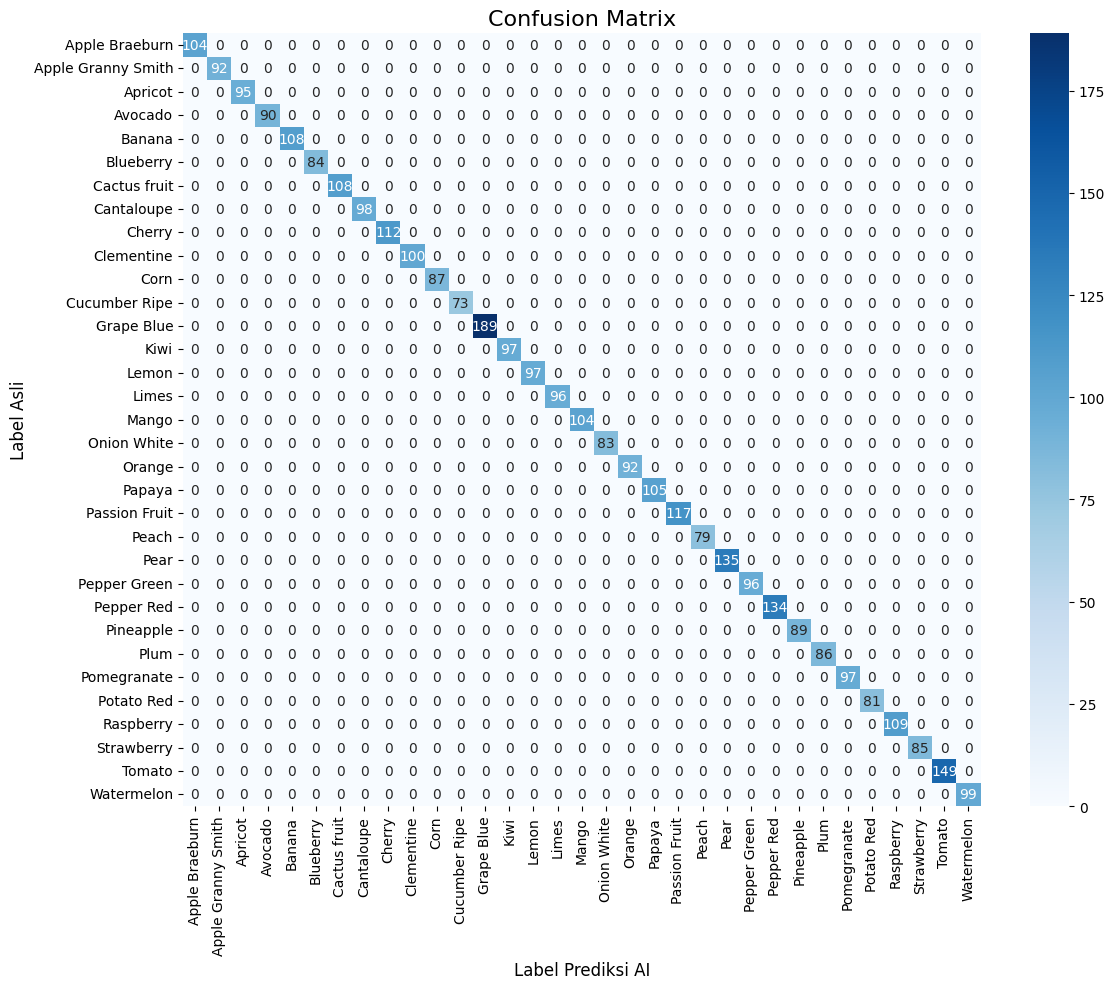

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# ==========================================
# 6. EVALUASI AKURASI & LOSS
# ==========================================
print("\n[INFO] Menghitung Evaluasi Model...")
val_loss, val_acc = model.evaluate(val_ds)
print(f"Akurasi Validasi : {val_acc * 100:.2f}%")
print(f"Loss Validasi    : {val_loss:.4f}")

# ==========================================
# 7. GRAFIK TRAINING (AKURASI & LOSS)
# ==========================================
print("\n[INFO] Membuat Grafik Performa Training...")
plt.figure(figsize=(14, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Grafik Akurasi')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Grafik Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('grafik_performa.png')
plt.show()

# ==========================================
# 8. CLASSIFICATION REPORT & CONFUSION MATRIX
# ==========================================
print("\n[INFO] Menghitung prediksi untuk Classification Report...")

# Cara yang lebih aman, cepat, dan rapi untuk mengekstrak data
y_true = np.concatenate([labels.numpy() for images, labels in val_ds], axis=0)
prediksi_mentah = model.predict(val_ds)
y_pred = np.argmax(prediksi_mentah, axis=1)

print("\n" + "="*50)
print("               CLASSIFICATION REPORT")
print("="*50)

# PERBAIKAN 1: Tambahkan labels parameter dan zero_division
# Agar tidak error jika ada buah yang tidak muncul di set validasi
print(classification_report(
    y_true, 
    y_pred, 
    target_names=class_names, 
    labels=range(num_classes),
    zero_division=0 
))

print("\n[INFO] Membuat Confusion Matrix...")
# PERBAIKAN 2: Paksa matriks berukuran pasti sesuai jumlah kelas (num_classes)
cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Label Asli', fontsize=12)
plt.xlabel('Label Prediksi AI', fontsize=12)
plt.xticks(rotation=90) 
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Load Model yang sudah dilatih
model = tf.keras.models.load_model('model_klasifikasi_makanan.h5')

# ==========================================
# PERBAIKAN: Daftar kelas disesuaikan dengan folder di datasetBuah2/train/train
# Harus urut abjad sesuai urutan TensorFlow membacanya
# ==========================================
class_names = [
    'Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 
    'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 
    'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 
    'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 
    'Mango', 'Onion White', 'Orange', 'Papaya', 
    'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 
    'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 
    'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 
    'Watermelon'
]

# Path foto yang mau diuji (Bisa diganti dengan gambar lain di test/test)
img_path = '"C:/Users/MyPC PRO/Downloads/images.jpg"' 

# 2. Load gambar dan sesuaikan ukurannya (Sesuai IMG_SIZE saat training: 224x224)
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Tambahkan batch axis menjadi (1, 224, 224, 3)

# 3. Prediksi Gambar
predictions = model.predict(img_array)

# Langsung ambil indeks ke-0 karena model sudah menggunakan aktivasi Softmax di layer terakhir
score = predictions[0]

# Ambil label dan nilai persentase tertinggi
label_terpilih = class_names[np.argmax(score)]
persentase_yakin = 100 * np.max(score)

# 4. Tampilkan Hasil dengan Gambar
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediksi: {label_terpilih}\nKeyakinan: {persentase_yakin:.2f}%", fontsize=14)
plt.show()

print(f"\n[HASIL] Gambar ini kemungkinan besar adalah: {label_terpilih}")
print(f"[SKOR] Tingkat keyakinan: {persentase_yakin:.2f}%")

OSError: [Errno 22] Invalid argument: '"C:\\Users\\MyPC PRO\\Downloads\\images.jpg"'